In [ ]:
Задание 7. Вариант 3 Выполнил: Радченко Анатолий Группа: МГК-53

Размерность данных: (569, 30)
Названия классов: ['malignant' 'benign']
Распределение классов:
 [212 357]

Обучающая выборка: 455 объектов
Тестовая выборка: 114 объектов

--- k-NN (k=5) без масштабирования ---
Accuracy: 0.9123
Classification report:
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114


--- Масштабирование + подбор k ---
Лучшее k = 3, Accuracy = 0.9825

--- Финальная модель (масштабирование + k=3) ---
Accuracy: 0.9825
Classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98     

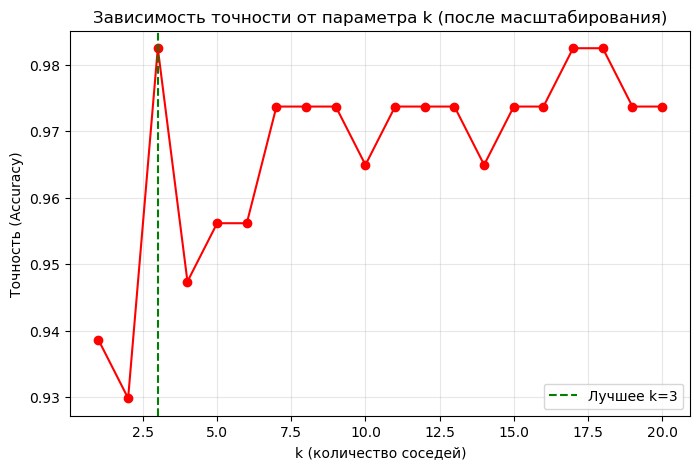

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


data = load_breast_cancer()
X = data.data          
y = data.target        

print("Размерность данных:", X.shape)
print("Названия классов:", data.target_names)
print("Распределение классов:\n", np.bincount(y))


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nОбучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")


knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train, y_train)
y_pred_default = knn_default.predict(X_test)


acc_default = accuracy_score(y_test, y_pred_default)
print(f"\n--- k-NN (k=5) без масштабирования ---")
print(f"Accuracy: {acc_default:.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred_default, target_names=data.target_names))


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


k_values = range(1, 21)
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    test_scores.append(accuracy_score(y_test, y_pred))

best_k = k_values[np.argmax(test_scores)]
best_acc = max(test_scores)

print(f"\n--- Масштабирование + подбор k ---")
print(f"Лучшее k = {best_k}, Accuracy = {best_acc:.4f}")


knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

print("\n--- Финальная модель (масштабирование + k={}) ---".format(best_k))
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))


plt.figure(figsize=(8, 5))
plt.plot(k_values, test_scores, 'o-', color='red', markersize=6)
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Лучшее k={best_k}')
plt.xlabel('k (количество соседей)')
plt.ylabel('Точность (Accuracy)')
plt.title('Зависимость точности от параметра k (после масштабирования)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()